In [1]:
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from visualize_ean_plotly import plot_ean_plotly, draw_ean_plotly, show_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries, propagate2
import headway_integration as hi
import numpy as np
from collections import defaultdict
import sys
from pathlib import Path as path

project_root = path(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.schematic_map.routing import (build_route,get_signal_nodes_on_route,)
from infra_data.scenarios import load_network_csv, load_headways
from tools.RailML2trip_data.reassign_trip_id import reassign_trip_ids_by_departure


# Import infrastructure and timetable, clean and prepare data

In [2]:
nodesDf = load_network_csv("nodes.csv", "node_id")
edgesDf = load_network_csv("edges.csv", "edge_id")
#edgesDf["length"] = (edgesDf["node_to"].map(nodesDf["pk_rel"])- edgesDf["node_from"].map(nodesDf["pk_rel"])).abs()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\230215 FBS Fpl 2026-NB-1443983-3.npy", allow_pickle=True).item()
trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\RidottoStamm6.npy", allow_pickle=True).item()
headway_dict = load_headways()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [3]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [4]:
trip_data, ordered_old_ids=reassign_trip_ids_by_departure(trip_data)

In [5]:
routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [6]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [7]:
#add side nodes to trip data

from copy import deepcopy

def add_side_nodes_to_trip_data(trip_data, nodesDf):
    """
    Return a copy of trip_data where terminal nodes are replaced by their
    '_side' counterpart, but only for trains running from Merano to Malles
    (i.e. decreasing pk_rel).

    A stop 'X' is replaced by 'X_side' only if:
      - 'X_side' exists in nodesDf, and
      - the train direction is Merano -> Malles.
    """
    trip_data_sides = deepcopy(trip_data)

    available_nodes = set(nodesDf.index)

    for train_id, stops in trip_data_sides.items():

        # Need at least two stops to infer direction
        if len(stops) < 2:
            continue

        pk0 = nodesDf.loc[stops[0][0], "pk_rel"]
        pk1 = nodesDf.loc[stops[1][0], "pk_rel"]

        # Merano -> Malles corresponds to decreasing pk_rel
        merano_to_malles = pk1 > pk0

        if not merano_to_malles:
            continue

        for i, (node, arr, dep, is_stop) in enumerate(stops):

            side_node = f"{node}_side"

            if side_node in available_nodes:
                stops[i] = (side_node, arr, dep, True)

    return trip_data_sides

In [8]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [9]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('Dev_LAC_01', 'Dev_LAC_02'): ['Dev_LAC_01', 'Pa_I_LAC_31_side', 'LAC_side', 'Pa_I_LAC_32_side', 'Dev_LAC_02'], ('Dev_LAC_02', 'Dev_COLD_01'): ['Dev_LAC_02', 'Pr_I_LAC_52', 'Pa_E_LAC_62', 'PL19', 'Pr_I_LAC_72', 'Pr_E_LAC_02', 'SblLac31026', 'HD_501_02', 'Pr_E_COLD_01', 'Pr_I_COLD_91', 'PL20', 'Pa_COLD_31', 'Dev_COLD_01'], ('Dev_STA_02', 'Dev_PL13_01'): ['Dev_STA_02', 'Pr_I_STA_52', 'Pa_E_STA_62', 'PL12', 'Pr_I_STA_72', 'Pr_E_STA_02', 'km52000', 'Dev_PL13_01'], ('Dev_PL13_01', 'Dev_PL15_01'): ['Dev_PL13_01', 'Pr_E_PL13_01_side', 'SblStab21529_side', 'Pr_I_PL13_51_side', 'PL13_side', 'Pr_I_PL13_52_side', 'Pr_E_PL13_02_side', 'Pr_E_CIA_01_side', 'Pa_CIA_31_side', 'CIA_side', 'Pa_CIA_32_side', 'PL14_side', 'Pr_I_CIA_62_side', 'Pr_E_CIA_02_side', 'HD_403_02_side', 'km55900_side', 'SblStab24529_side', 'Pr_E_PL15_01_side', 'Dev_PL15_01'], ('ME_side', 'Dev_LAG_02'): ['ME_side', 'Dev_ME_01_side', 'Pa_ME_side', 'SC_ME_side', 'Pr_ME_LT_side', 'Pr_E_LAG_01_side', 'Pa_LAG_31_side', 'LAG_si

In [10]:
# Remove opposite-direction headways on double-track chains
headway_dict = deepcopy(headway_dict)

# --------------------------------------------------
# Step 1: Count how many infrastructure edges occupy
# each elementary pk interval
# --------------------------------------------------

pk_values = sorted(nodesDf["pk_rel"].unique())

interval_count = defaultdict(int)

for _, edge in edgesDf.iterrows():

    pk1 = nodesDf.loc[edge["node_from"], "pk_rel"]
    pk2 = nodesDf.loc[edge["node_to"], "pk_rel"]

    a, b = sorted((pk1, pk2))

    for left, right in zip(pk_values[:-1], pk_values[1:]):
        if left >= a and right <= b:
            interval_count[(left, right)] += 1


# --------------------------------------------------
# Step 2: Determine whether each chain is entirely
# on double track
# --------------------------------------------------

double_track_chains = set()

for chain_key, chain_nodes in chains.items():

    is_double = True

    for n1, n2 in zip(chain_nodes[:-1], chain_nodes[1:]):

        pk1 = nodesDf.loc[n1, "pk_rel"]
        pk2 = nodesDf.loc[n2, "pk_rel"]

        a, b = sorted((pk1, pk2))

        for left, right in zip(pk_values[:-1], pk_values[1:]):
            if left >= a and right <= b:
                if interval_count[(left, right)] < 2:
                    is_double = False
                    break

        if not is_double:
            break

    if is_double:
        double_track_chains.add(chain_key)


# --------------------------------------------------
# Step 3: Remove opposite-direction headways
# on double-track chains
# --------------------------------------------------

for key in list(headway_dict):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_chains:

        opposite = (
            ("up" in cat1 and "down" in cat2)
            or
            ("down" in cat1 and "up" in cat2)
        )

        if opposite:
            del headway_dict[key]

# Build EAN, add headway constraints

In [11]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)
print("Constraints:", constraints)
print("Skipped:", skipped)

G_scheduled = build_ean(trip_data_enriched)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

[assemble_headway_constraints] 89 entries skipped -- inspect `skipped` for details (unmatched chains/categories).
Constraints: [{'train_i': 1, 'seq_i': 6, 'event_i': 'dep', 'train_j': 2, 'seq_j': 4, 'event_j': 'dep', 'min_headway': 356.1638848400992, 'resource': ('Dev_TEL_01', 'Dev_01_PLA')}, {'train_i': 8, 'seq_i': 28, 'event_i': 'dep', 'train_j': 9, 'seq_j': 28, 'event_j': 'dep', 'min_headway': 96.44498789287184, 'resource': ('Dev_TEL_01', 'Dev_01_PLA')}, {'train_i': 14, 'seq_i': 28, 'event_i': 'dep', 'train_j': 15, 'seq_j': 28, 'event_j': 'dep', 'min_headway': 96.44498789287184, 'resource': ('Dev_TEL_01', 'Dev_01_PLA')}, {'train_i': 15, 'seq_i': 28, 'event_i': 'dep', 'train_j': 16, 'seq_j': 20, 'event_j': 'dep', 'min_headway': 96.44498789285265, 'resource': ('Dev_TEL_01', 'Dev_01_PLA')}, {'train_i': 10, 'seq_i': 12, 'event_i': 'dep', 'train_j': 11, 'seq_j': 16, 'event_j': 'dep', 'min_headway': 192.31082743920922, 'resource': ('Dev_LAC_01', 'Dev_LAC_02')}, {'train_i': 13, 'seq_i': 12

# Stochastic Perturbation

In [12]:
node_perturbations, edge_perturbations = hi.generate_perturbation_scenarios(G_scheduled,
    n_scenarios=3,
    entry_delay_mean=5*60,
    entry_delay_std=2*60,
    running_delay_mean=0*60,
    running_delay_std=1*60,
    seed=42,
)

## Propagation

### Plotly

In [13]:
realized_graphs = []

for node_p, edge_p in zip(
    node_perturbations,
    edge_perturbations,
):

    G_realized = propagate2(
        G_scheduled,
        edge_perturbations=edge_p,
    )

    realized_graphs.append(G_realized)


fig, ax = plot_ean_plotly(
    G_scheduled,
    nodesDf,
    edgesDf,
    title="Scheduled vs realized",
)


for G_realized in realized_graphs:

    draw_ean_plotly(
        G_realized,
        nodesDf,
        ax,
        alpha=0.2,
        linewidth_scale=0.8,
    )


show_ean(
    fig,
    filename="ean_visualization.html",
    auto_open=True,
)

EAN visualization written to: C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\ean_simulation\ean_visualization.html


WindowsPath('ean_visualization.html')

### Matlib

In [14]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations, edge_perturbations):

    G_realized = propagate2(
        G_scheduled,
        edge_perturbations=edge_p,
    )

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled,nodesDf,edgesDf,title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [14]:
def format_time(seconds):
    seconds = round(seconds)
    sign = "-" if seconds < 0 else ""
    seconds = abs(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{sign}{hours:02d}:{minutes:02d}:{seconds:02d}"


def get_train_times(G):
    """Returns {train_id: {"dep": ..., "arr": ...}}."""
    times = {}
    trains = sorted({data["train"] for _, data in G.nodes(data=True) if "train" in data})

    for train in trains:
        events = [data for _, data in G.nodes(data=True) if data.get("train") == train]
        times[train] = {
            "dep": min(e["time"] for e in events if e["event"] == "dep"),
            "arr": max(e["time"] for e in events if e["event"] == "arr")
        }

    return times


def compare_to_schedule(G_scheduled, G_realized):
    scheduled = get_train_times(G_scheduled)
    realized = get_train_times(G_realized)

    report = {}

    for train in scheduled:
        report[train] = {
            "dep_sched": scheduled[train]["dep"],
            "dep_real": realized[train]["dep"],
            "arr_sched": scheduled[train]["arr"],
            "arr_real": realized[train]["arr"],
            "delay": realized[train]["arr"] - scheduled[train]["arr"]
        }

    return report


for i, (node_perturbation, edge_perturbation, G_realized) in enumerate(
    zip(node_perturbations, edge_perturbations, realized_graphs)
):
    arrival_report = compare_to_schedule(G_scheduled, G_realized)

    print(f"\nScenario {i}")
    print("-" * 100)

    for train in sorted(arrival_report):
        r = arrival_report[train]

        print(
            f"Train {train:>2}: "
            f"dep_sched={format_time(r['dep_sched'])}   "
            f"dep_real={format_time(r['dep_real'])}   "
            f"arr_sched={format_time(r['arr_sched'])}   "
            f"arr_real={format_time(r['arr_real'])}   "
            f"delay={format_time(r['delay'])}"
        )


Scenario 0
----------------------------------------------------------------------------------------------------
Train  1: dep_sched=08:52:18   dep_real=08:52:18   arr_sched=10:24:44   arr_real=10:27:29   delay=00:02:45
Train  2: dep_sched=09:31:18   dep_real=09:31:18   arr_sched=10:29:43   arr_real=10:36:33   delay=00:06:50
Train  3: dep_sched=09:52:18   dep_real=09:52:18   arr_sched=11:24:44   arr_real=11:32:03   delay=00:07:19
Train  4: dep_sched=10:31:18   dep_real=10:31:18   arr_sched=11:29:43   arr_real=11:48:34   delay=00:18:51
Train  5: dep_sched=10:34:18   dep_real=10:35:34   arr_sched=11:54:56   arr_real=12:13:07   delay=00:18:11
Train  6: dep_sched=10:52:18   dep_real=10:52:18   arr_sched=12:24:44   arr_real=12:41:42   delay=00:16:58
Train  7: dep_sched=11:31:18   dep_real=11:31:18   arr_sched=12:29:43   arr_real=12:50:19   delay=00:20:36
Train  8: dep_sched=08:35:18   dep_real=08:35:18   arr_sched=10:07:24   arr_real=10:10:48   delay=00:03:24
Train  9: dep_sched=09:04:18   

# Manual Perturbation

## Propagation

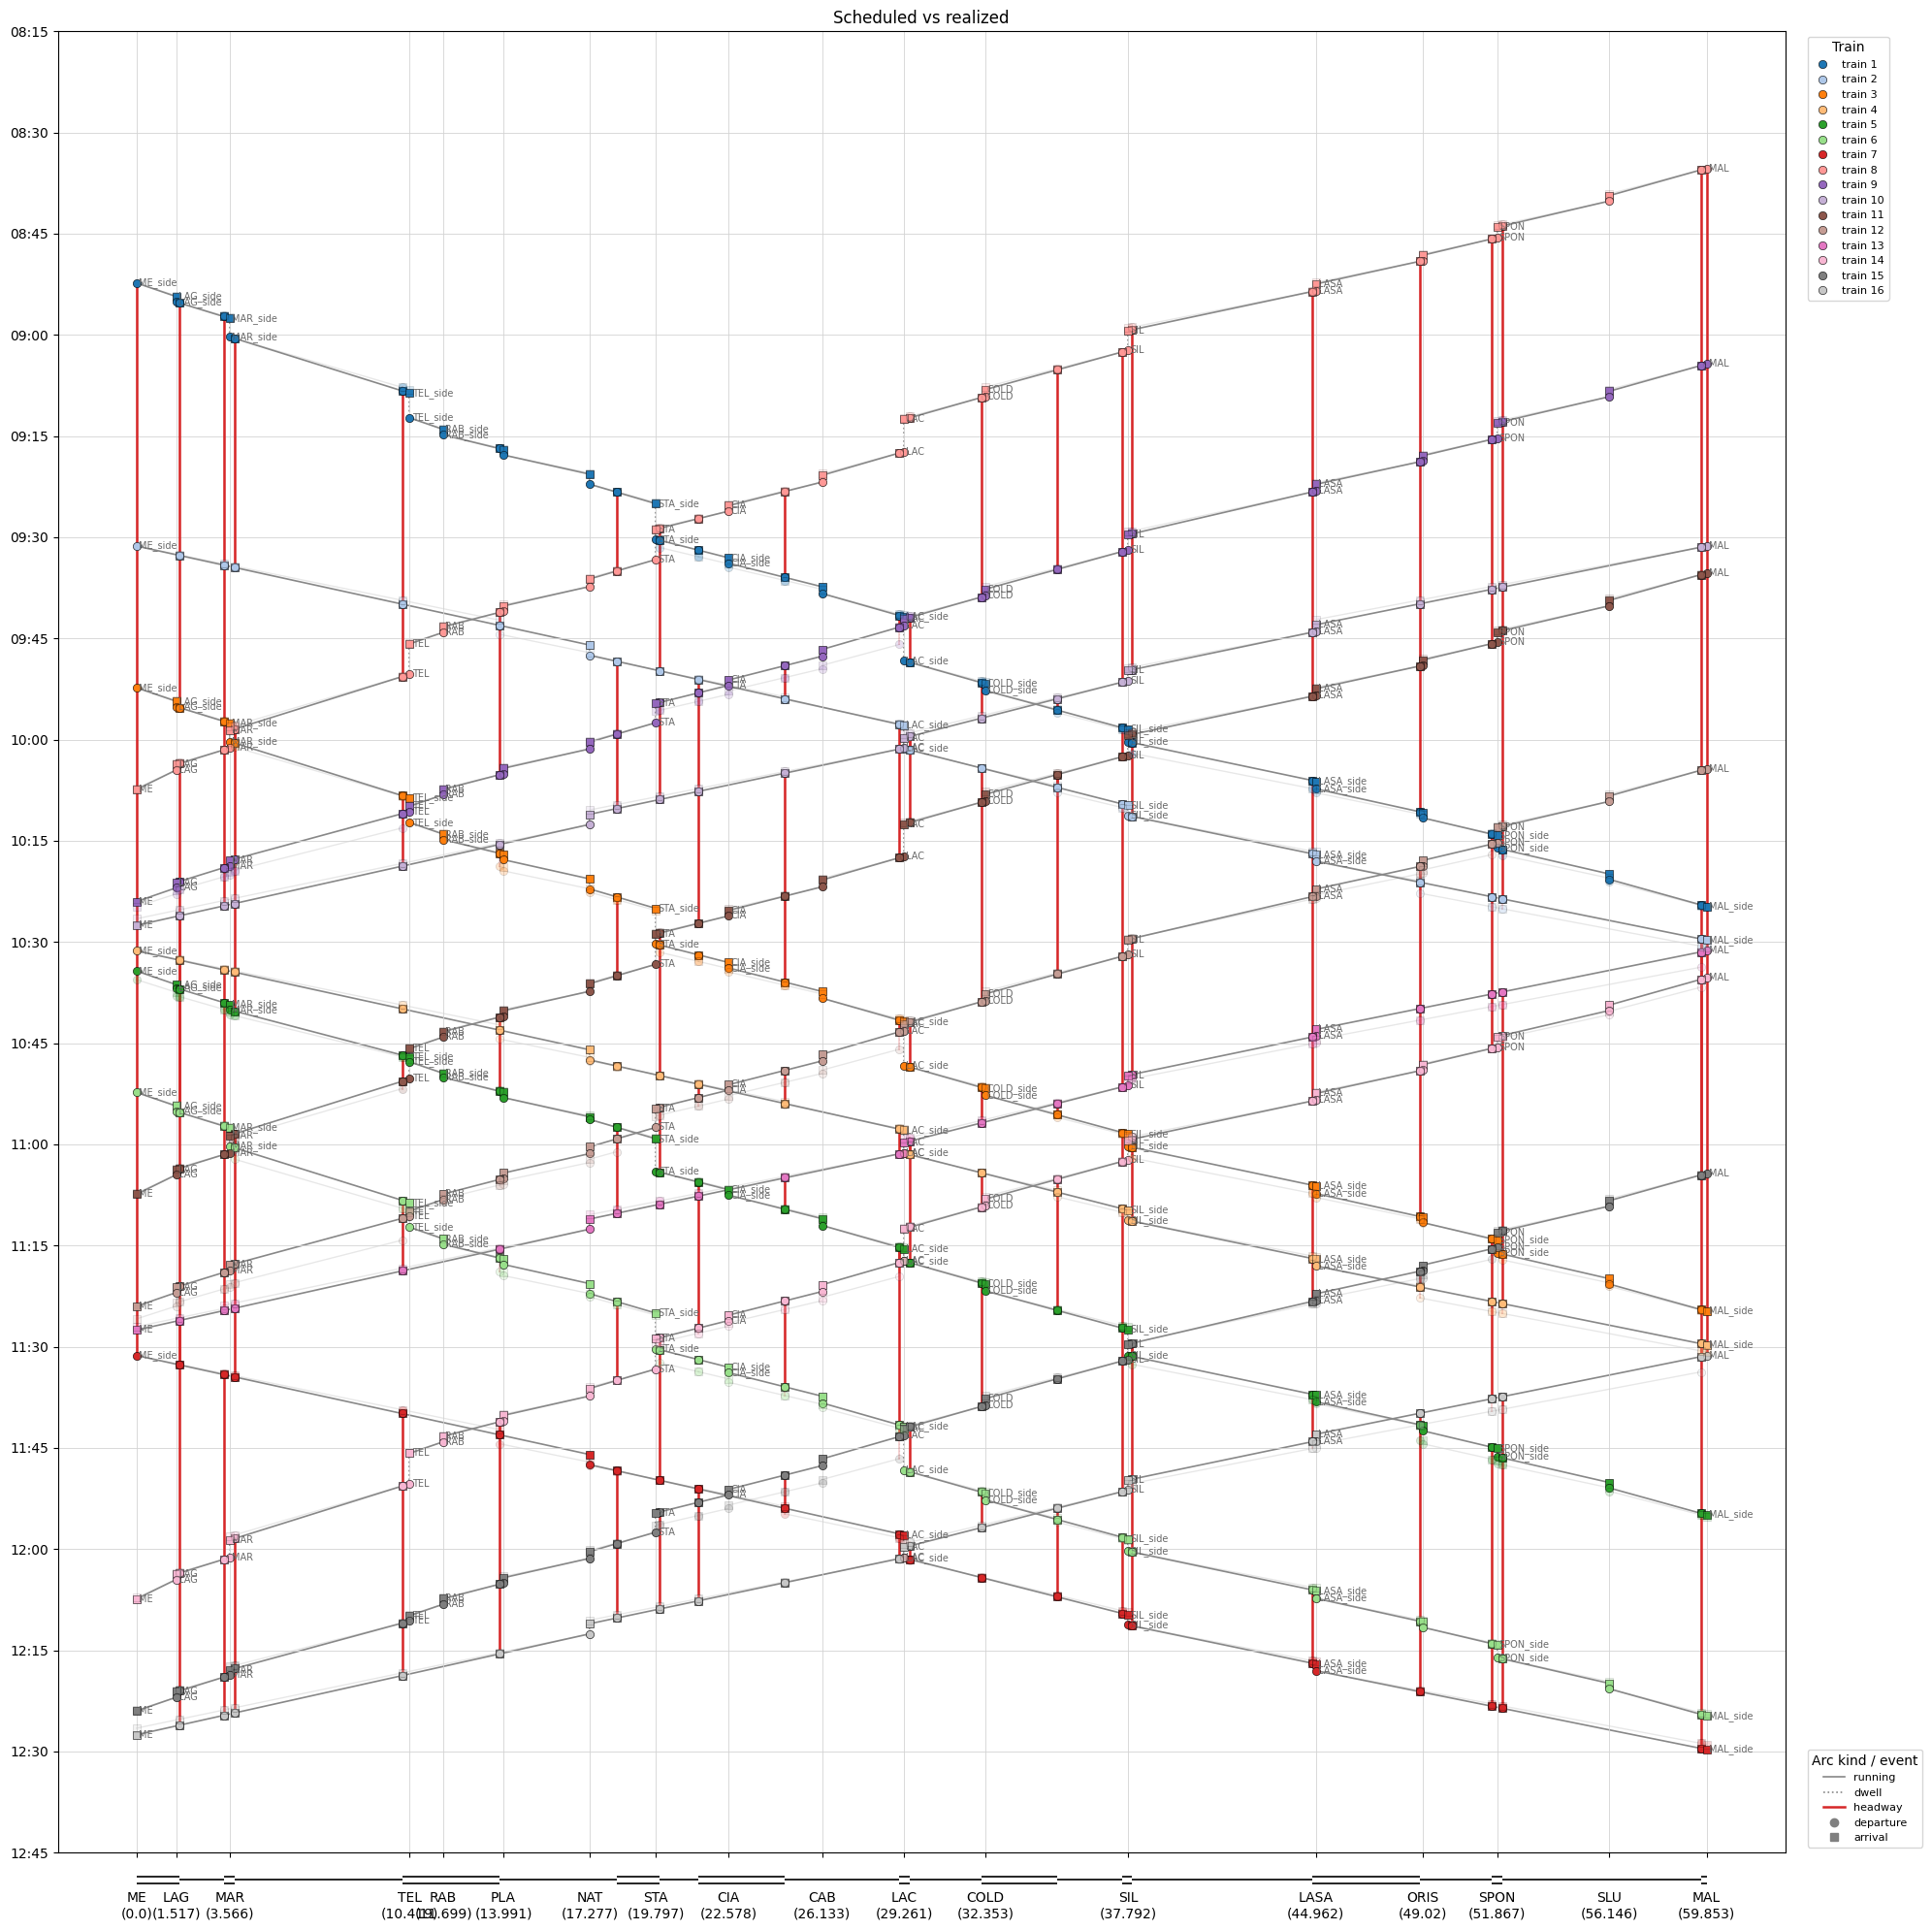

In [ ]:
#inject delays manually
running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]
edge = running_edges[0]  

#perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = [{edge:0}]


realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [ ]:
for i, (node_perturbation, edge_perturbation, G_realized) in enumerate(
    zip(node_perturbations, edge_perturbations, realized_graphs)
):
    arrival_report = compare_to_schedule(G_scheduled, G_realized)

    print(f"\nScenario {i}")
    print("-" * 100)

    for train in sorted(arrival_report):
        r = arrival_report[train]

        print(
            f"Train {train:>2}: "
            f"dep_sched={format_time(r['dep_sched'])}   "
            f"dep_real={format_time(r['dep_real'])}   "
            f"arr_sched={format_time(r['arr_sched'])}   "
            f"arr_real={format_time(r['arr_real'])}   "
            f"delay={format_time(r['delay'])}"
        )


Scenario 0
----------------------------------------------------------------------------------------------------
Train  1: dep_sched=08:52:18   dep_real=08:52:18   arr_sched=10:24:44   arr_real=10:24:48   delay=00:00:04
Train  2: dep_sched=09:31:18   dep_real=09:31:18   arr_sched=10:29:43   arr_real=10:30:47   delay=00:01:04
Train  3: dep_sched=09:52:18   dep_real=09:52:18   arr_sched=11:24:44   arr_real=11:24:48   delay=00:00:04
Train  4: dep_sched=10:31:18   dep_real=10:31:18   arr_sched=11:29:43   arr_real=11:30:47   delay=00:01:04
Train  5: dep_sched=10:34:18   dep_real=10:35:34   arr_sched=11:54:56   arr_real=11:55:10   delay=00:00:14
Train  6: dep_sched=10:52:18   dep_real=10:52:18   arr_sched=12:24:44   arr_real=12:24:28   delay=-00:00:16
Train  7: dep_sched=11:31:18   dep_real=11:31:18   arr_sched=12:29:43   arr_real=12:28:57   delay=-00:00:46
Train  8: dep_sched=08:35:18   dep_real=08:35:18   arr_sched=10:07:24   arr_real=10:07:13   delay=-00:00:11
Train  9: dep_sched=09:04:18